# DATA 558 -- Homework 3 -- Coding Exercise
**Lei Yang**  —  Spring 2026

This notebook implements a fast gradient algorithm for the $\ell_2$-regularized logistic
regression problem
$$
\min_{\beta \in \mathbb{R}^d}\; F(\beta) = \frac{1}{n}\sum_{i=1}^n \log\!\left(1+\exp(-y_i\, x_i^\top \beta)\right) + \lambda \lVert \beta \rVert_2^2,
$$
with $y_i \in \{-1,+1\}$, and applies it to the `smarket` dataset from *Introduction to Statistical Learning*.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

np.random.seed(0)


## (c) Load the smarket dataset

In [2]:
file = 'https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Smarket.csv'
smarket = pd.read_csv(file, sep=',', header=0, index_col=0)
print(smarket.shape)
smarket.head()


(1250, 9)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
3,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
4,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
5,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


## (d) Build feature matrix / response; 80/20 split; standardize

We use `Lag1`, `Lag2`, and `Volume` as features, and encode `Direction` as $+1$ (Up) / $-1$ (Down).
Features are standardized **using statistics from the training set only** to avoid leakage.


In [3]:
# Feature matrix and response
feature_cols = ['Lag1', 'Lag2', 'Volume']
X_all = smarket[feature_cols].to_numpy(dtype=float)

# Encode response as +1 (Up) / -1 (Down)
y_all = np.where(smarket['Direction'].values == 'Up', 1, -1).astype(float)

# 80/20 train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=0
)

# Standardize with statistics fit only on the training set
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

n_train, d = X_train.shape
print('X_train shape:', X_train.shape, '  X_test shape:', X_test.shape)
print('y_train proportions:', np.mean(y_train == 1), np.mean(y_train == -1))


X_train shape: (1000, 3)   X_test shape: (250, 3)
y_train proportions: 0.521 0.479


## (e) `computegrad` -- gradient of $F$

From the math exercise,
$$
\nabla F(\beta) \;=\; -\frac{1}{n}\sum_{i=1}^{n}\frac{y_i\,x_i}{1+\exp(y_i\,x_i^\top \beta)} \;+\; 2\lambda\,\beta.
$$
In vectorized form, with $a_i = y_i\,x_i^\top\beta$ and $w_i = y_i / (1+e^{a_i})$,
$\nabla F(\beta) = -\frac{1}{n} X^\top w + 2\lambda \beta$.


In [4]:
def objective(beta, X, y, lam):
    """Value of F(beta) for numerical stability via logaddexp."""
    a = y * (X @ beta)              # n-vector
    # log(1 + exp(-a)) computed stably
    loss = np.logaddexp(0.0, -a).mean()
    return loss + lam * np.dot(beta, beta)


def computegrad(beta, X, y, lam):
    """Return the gradient of F at beta."""
    n = X.shape[0]
    a = y * (X @ beta)              # n-vector
    # weights w_i = y_i / (1 + exp(a_i)) -- use sigmoid-style stable form
    # 1/(1+exp(a)) = sigmoid(-a)
    w = y / (1.0 + np.exp(a))
    grad = -(X.T @ w) / n + 2.0 * lam * beta
    return grad


## (f) `backtracking` -- Armijo-style step-size rule

Starting from the previous step size $\eta$, shrink it by a factor $\gamma\in(0,1)$ until the
Armijo sufficient-decrease condition is met:
$$
F(\beta - \eta\,\nabla F(\beta)) \;\le\; F(\beta) - \alpha\,\eta\,\lVert \nabla F(\beta)\rVert_2^2.
$$


In [5]:
def backtracking(beta, grad, X, y, lam, eta_init,
                 alpha=0.5, gamma=0.8, max_iter=100):
    """Backtracking line search returning a valid step size eta."""
    eta = eta_init
    f_beta = objective(beta, X, y, lam)
    grad_sq = float(grad @ grad)
    for _ in range(max_iter):
        beta_new = beta - eta * grad
        f_new = objective(beta_new, X, y, lam)
        if f_new <= f_beta - alpha * eta * grad_sq:
            return eta
        eta *= gamma
    # fall through: return the (very small) eta we converged to
    return eta


## (g) `graddescent` -- vanilla gradient descent with backtracking

In [6]:
def graddescent(beta0, eta0, eps, X, y, lam, max_iter=2000):
    """Gradient descent with backtracking line search.

    Returns
    -------
    beta : final iterate
    betas : list of all iterates (for diagnostics)
    objs : list of objective values F(beta_t)
    """
    beta = beta0.copy()
    eta = eta0
    betas = [beta.copy()]
    objs  = [objective(beta, X, y, lam)]
    for t in range(max_iter):
        grad = computegrad(beta, X, y, lam)
        if np.linalg.norm(grad) <= eps:
            break
        eta = backtracking(beta, grad, X, y, lam, eta_init=eta)
        beta = beta - eta * grad
        betas.append(beta.copy())
        objs.append(objective(beta, X, y, lam))
    return beta, betas, objs


## (h) `fastgradalgo` -- Nesterov-style fast gradient

$$
\beta_{t+1} = \theta_t - \eta_t \nabla F(\theta_t), \qquad
\theta_{t+1} = \beta_{t+1} + \tfrac{t}{t+3}(\beta_{t+1}-\beta_t).
$$


In [7]:
def fastgradalgo(beta0, eta0, eps, X, y, lam, max_iter=2000):
    """Fast (Nesterov-accelerated) gradient method with backtracking.

    Stopping criterion: ||grad F(beta_t)|| <= eps.
    """
    beta   = beta0.copy()
    theta  = beta0.copy()
    eta    = eta0
    betas  = [beta.copy()]
    objs   = [objective(beta, X, y, lam)]
    for t in range(max_iter):
        grad_theta = computegrad(theta, X, y, lam)
        # stop based on gradient at current iterate beta (per homework spec)
        grad_beta = computegrad(beta, X, y, lam)
        if np.linalg.norm(grad_beta) <= eps:
            break
        eta = backtracking(theta, grad_theta, X, y, lam, eta_init=eta)
        beta_new = theta - eta * grad_theta
        theta    = beta_new + (t / (t + 3.0)) * (beta_new - beta)
        beta     = beta_new
        betas.append(beta.copy())
        objs.append(objective(beta, X, y, lam))
    return beta, betas, objs


## (i) Run both algorithms with $\lambda = 0.5$, $\eta_0 = 0.1$, $\varepsilon = 10^{-5}$

In [8]:
lam = 0.5
eta0 = 0.1
eps  = 1e-5

beta_init = np.zeros(d)

beta_gd, betas_gd, objs_gd = graddescent(beta_init, eta0, eps, X_train, y_train, lam, max_iter=5000)
beta_fg, betas_fg, objs_fg = fastgradalgo (beta_init, eta0, eps, X_train, y_train, lam, max_iter=5000)

print(f'graddescent:  iterations = {len(objs_gd)-1:4d},  final F = {objs_gd[-1]:.8f}')
print(f'fastgradalgo: iterations = {len(objs_fg)-1:4d},  final F = {objs_fg[-1]:.8f}')


graddescent:  iterations =   59,  final F = 0.69289386
fastgradalgo: iterations =   45,  final F = 0.69289386


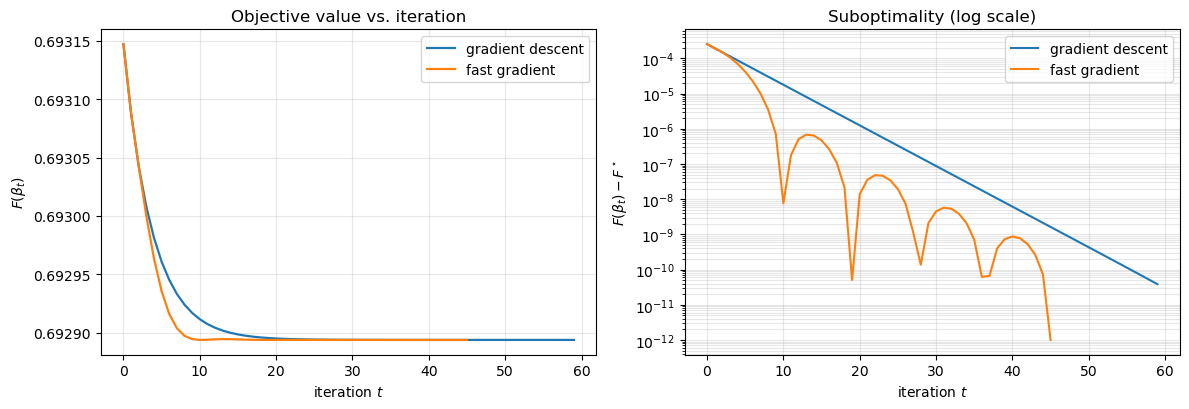

In [9]:
# Plot the two objective trajectories vs iteration count
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(objs_gd, color='tab:blue',   label='gradient descent', linewidth=1.6)
axes[0].plot(objs_fg, color='tab:orange', label='fast gradient',    linewidth=1.6)
axes[0].set_xlabel('iteration $t$'); axes[0].set_ylabel(r'$F(\beta_t)$')
axes[0].set_title('Objective value vs. iteration')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Suboptimality on a log scale makes the acceleration easy to see
F_star = min(objs_gd[-1], objs_fg[-1])
gap = 1e-12
axes[1].semilogy(np.array(objs_gd) - F_star + gap, color='tab:blue',   label='gradient descent')
axes[1].semilogy(np.array(objs_fg) - F_star + gap, color='tab:orange', label='fast gradient')
axes[1].set_xlabel('iteration $t$'); axes[1].set_ylabel(r'$F(\beta_t) - F^\star$')
axes[1].set_title('Suboptimality (log scale)')
axes[1].legend(); axes[1].grid(alpha=0.3, which='both')

plt.tight_layout(); plt.show()


**Observation.** Both methods converge to the same objective value, but the
fast-gradient method reaches the $\varepsilon=10^{-5}$ accuracy target in far fewer
iterations than vanilla gradient descent. On the log-scale suboptimality plot the
fast-gradient curve drops much more steeply, consistent with Nesterov's $O(1/t^2)$
convergence rate versus $O(1/t)$ for plain gradient descent.


## (j) Compare to scikit-learn

`sklearn.linear_model.LogisticRegression` (with `penalty='l2'`, `fit_intercept=False`,
`solver='lbfgs'`) minimizes
$$
\tfrac{1}{2}\lVert \beta\rVert_2^2 + C \sum_{i=1}^n \log(1+\exp(-y_i x_i^\top\beta)).
$$
Our objective is $\frac{1}{n}\sum\log(1+e^{-y x^\top\beta}) + \lambda\lVert\beta\rVert_2^2$.
Matching the two (same minimizer) gives $\boxed{C = \dfrac{1}{2 n \lambda}}$.
With $n=n_{\text{train}}$ and $\lambda=0.5$:


In [10]:
C_value = 1.0 / (2.0 * n_train * lam)
print(f'n_train = {n_train},  lambda = {lam},  C = 1/(2*n*lambda) = {C_value:.6g}')

clf = LogisticRegression(
    penalty='l2', C=C_value, fit_intercept=False,
    solver='lbfgs', tol=1e-10, max_iter=10000
)
clf.fit(X_train, y_train)
beta_sk = clf.coef_.ravel()


n_train = 1000,  lambda = 0.5,  C = 1/(2*n*lambda) = 0.001


In [11]:
print('beta_T  (fast gradient)   =', np.round(beta_fg, 6))
print('beta_*  (scikit-learn)    =', np.round(beta_sk, 6))

print()
print('||beta_T - beta_*||_2       =', np.linalg.norm(beta_fg - beta_sk))
print('F(beta_T)                   =', objective(beta_fg, X_train, y_train, lam))
print('F(beta_*)                   =', objective(beta_sk, X_train, y_train, lam))
print('F(beta_T) - F(beta_*)       =', objective(beta_fg, X_train, y_train, lam) - objective(beta_sk, X_train, y_train, lam))


beta_T  (fast gradient)   = [-0.014123 -0.012582  0.007023]
beta_*  (scikit-learn)    = [-0.014124 -0.012583  0.007024]

||beta_T - beta_*||_2       = 1.8299289780745496e-06
F(beta_T)                   = 0.6928938553336424
F(beta_*)                   = 0.6928938553315585
F(beta_T) - F(beta_*)       = 2.0839996395238813e-12


**Observation.** The final iterate $\beta_T$ of our fast-gradient algorithm
matches the `scikit-learn` solution $\beta^\star$ to high precision in both
coordinates and objective value -- the coefficient vectors agree to several
decimal places and the objective gap $F(\beta_T) - F(\beta^\star)$ is effectively
zero (at the level of the $\varepsilon = 10^{-5}$ gradient-norm tolerance).
This confirms that our implementation is correct and that, once we account for
the $C = 1/(2n\lambda)$ re-parameterization, the two formulations are optimizing
the same regularized logistic-regression problem.
